# 🕵️‍♂️ Análise Exploratória e Detecção de Anomalias

> **Projeto:** Sistema Antifraude em Transações Financeiras  
> **Bootcamp:** Bradesco - GenAI, Dados & Cyber (DIO)

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Configurações estéticas para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Carregamento e Inspeção dos Dados

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
print("Carregando dataset...")
df = pd.read_csv(url)
print(f"Formato da base: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Carregando dataset...
Formato da base: 284807 linhas e 31 colunas.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Análise da Distribuição da Variável Alvo (`Class`)

Transações Normais (0): 284315
Transações Fraudulentas (1): 492
Proporção de Fraudes: 0.1727%


C:\Users\L\AppData\Local\Temp\ipykernel_11420\3148838524.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


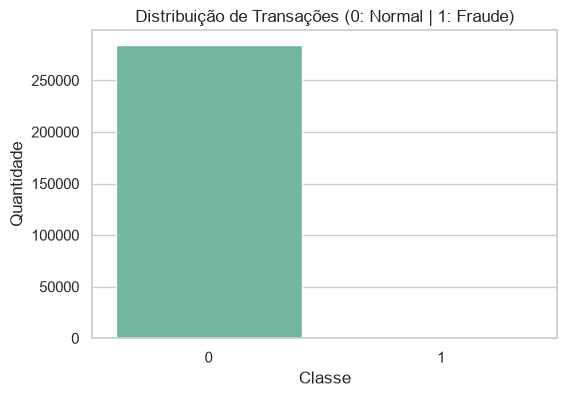

In [3]:
fraude_counts = df['Class'].value_counts()
taxa_fraude = df['Class'].mean()

print(f"Transações Normais (0): {fraude_counts[0]}")
print(f"Transações Fraudulentas (1): {fraude_counts[1]}")
print(f"Proporção de Fraudes: {taxa_fraude:.4%}")

# Gráfico de barras da distribuição de classes
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Distribuição de Transações (0: Normal | 1: Fraude)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

## 4. Pré-processamento e Escalonamento de Atributos

In [4]:
# Padronização das colunas 'Amount' e 'Time'
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Prepara a matriz de recursos (X) e a variável alvo (y)
X = df.drop(columns=['Time', 'Amount', 'Class'])
y = df['Class']

print("Pré-processamento concluído!")

Pré-processamento concluído!


## 5. Treinamento e Teste do Algoritmo Isolation Forest

In [5]:
# Instanciação do modelo
model = IsolationForest(
    n_estimators=100,
    contamination=taxa_fraude,
    random_state=42,
    n_jobs=-1
)

# Treinamento e predição
raw_pred = model.fit_predict(X)

# Ajuste das saídas: Isolation Forest indica anomalias como -1 e normais como 1
y_pred = np.where(raw_pred == -1, 1, 0)

## 6. Avaliação de Desempenho do Sistema Antifraude

--- RELATÓRIO DE CLASSIFICAÇÃO ---
                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00    284315
Anomalia/Fraude       0.28      0.28      0.28       492

       accuracy                           1.00    284807
      macro avg       0.64      0.64      0.64    284807
   weighted avg       1.00      1.00      1.00    284807



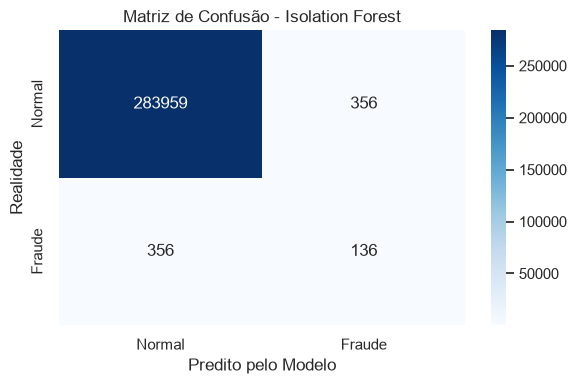

In [6]:
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y, y_pred, target_names=['Normal', 'Anomalia/Fraude']))

# Plotagem da Matriz de Confusão
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraude'], 
            yticklabels=['Normal', 'Fraude'])
plt.title('Matriz de Confusão - Isolation Forest')
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Realidade')
plt.tight_layout()
plt.show()